# Классификация: интервалы, нарезанные ЭКГ и объединение
Вероятностные выходы class-balanced boosting — модельные оценки, не клинически откалиброванные вероятности. Порог выбирается на validation; редкие классы без достаточного validation support используют 0.5 с явным ограничением.

In [1]:
from pathlib import Path
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd()
if not (ROOT / 'ecg_project').exists(): ROOT = ROOT.parent
os.chdir(ROOT)
def read_json(path): return json.loads(Path(path).read_text(encoding='utf-8'))


In [2]:
m=read_json('artifacts/record_models/metrics.json')
rows=[]
for mode,splits in m.items():
    for split,metrics in splits.items():
        if split=='external_long':continue
        rows.append(dict(mode=mode,split=split,macro_auroc=metrics['macro_auroc'],macro_f1=metrics['macro_f1']))
pd.DataFrame(rows)

,mode,split,macro_auroc,macro_f1
0,interval,valid,0.904424,0.479171
1,interval,test,0.876315,0.469874
2,interval,external,0.915678,0.550072
3,waveform,valid,0.834720,0.408270
4,waveform,test,0.835625,0.390435
5,waveform,external,0.803683,0.377779
6,fusion,valid,0.902302,0.493943
7,fusion,test,0.898059,0.501761
8,fusion,external,0.901367,0.504865


In [3]:
selection=read_json('artifacts/record_models/selection.json'); print(selection)
pd.DataFrame(m[selection['selected']]['test']['per_class']).T

{'selected': 'interval', 'criterion': 'validation macro AUROC', 'unsupported': {'VT': 1}}


,positive,negative,auroc,auprc,precision,recall,f1,threshold,prevalence
AF,31.0,469.0,0.988445,0.912343,0.925926,0.806452,0.862069,0.65,0.062
PVC,0.0,500.0,NaN,NaN,0.000000,0.000000,0.000000,0.50,0.000
SVEB,13.0,487.0,0.703048,0.162710,0.090909,0.307692,0.140351,0.10,0.026
AVB1,23.0,477.0,0.906754,0.411892,0.245902,0.652174,0.357143,0.05,0.046
AVB2,0.0,500.0,NaN,NaN,0.000000,0.000000,0.000000,0.50,0.000
AVB3,0.0,500.0,NaN,NaN,0.000000,0.000000,0.000000,0.50,0.000
AVB,23.0,477.0,0.924073,0.450514,0.313725,0.695652,0.432432,0.35,0.046
IVCD,80.0,420.0,0.859256,0.655480,0.809524,0.425000,0.557377,0.70,0.160


AUROC отсутствует, если в выборке нет положительного или отрицательного класса. Общую метку 30-минутной StPetersburg записи нельзя считать подтверждением события в первых 30 секундах; exploratory_long не входит в основной вывод о качестве.

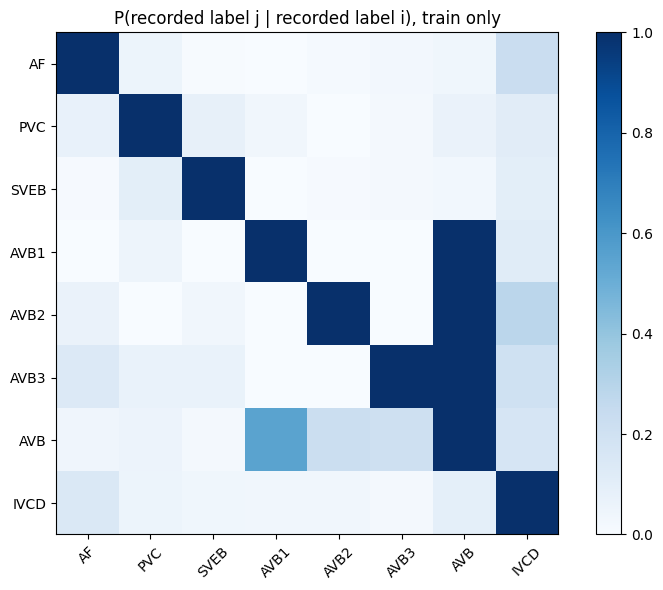

In [4]:
co=read_json('artifacts/record_models/label_dependencies.json')
fig,ax=plt.subplots(figsize=(8,6)); im=ax.imshow(co['conditional'],vmin=0,vmax=1,cmap='Blues'); ax.set_xticks(range(len(co['classes'])),co['classes'],rotation=45); ax.set_yticks(range(len(co['classes'])),co['classes']); ax.set_title('P(recorded label j | recorded label i), train only'); fig.colorbar(im); plt.tight_layout(); plt.show()

Это совместная встречаемость записанных меток. Она включает особенности кодирования источников и не доказывает причинную связь заболеваний.

In [5]:
b=read_json('artifacts/beat_models/metrics.json')
rows=[]
for mode,splits in b.items():
    for split,v in splits.items():
        for c in ['N','S','V','F','Q']:
            rows.append(dict(mode=mode,split=split,beat_class=c,f1_matched=v[c]['f1-score'],recall_end_to_end=v[c]['end_to_end_recall'],precision_end_to_end=v[c]['end_to_end_precision'],support=v[c]['all_reference_support']))
pd.DataFrame(rows)

,mode,split,beat_class,f1_matched,recall_end_to_end,precision_end_to_end,support
0,interval,valid,N,0.945312,0.914102,0.962865,7148
1,interval,valid,S,0.180077,0.239796,0.144172,196
2,interval,valid,V,0.666194,0.736677,0.504834,638
3,interval,valid,F,0.000000,0.000000,0.000000,20
4,interval,valid,Q,0.453125,0.276190,0.878788,105
5,interval,test,N,0.956041,0.949906,0.960941,45894
6,interval,test,S,0.147436,0.117048,0.198962,1965
7,interval,test,V,0.846009,0.921006,0.695537,3418
8,interval,test,F,0.231343,0.397436,0.161964,390
9,interval,test,Q,0.000000,0.000000,0.000000,8


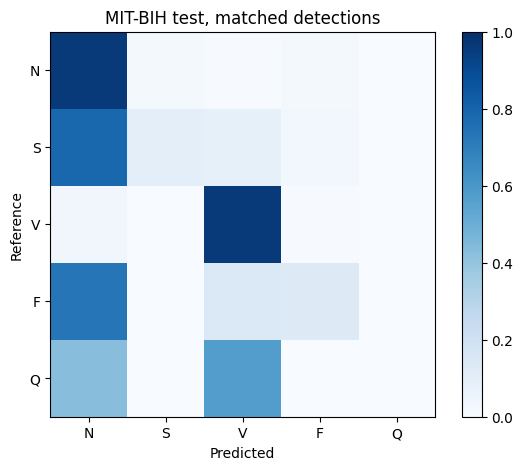

In [6]:
best=read_json('artifacts/beat_models/selection.json')['selected']
cm=np.array(b[best]['test']['confusion_matrix']); fig,ax=plt.subplots(figsize=(7,5)); im=ax.imshow(cm/np.maximum(cm.sum(1,keepdims=True),1),vmin=0,vmax=1,cmap='Blues'); names=['N','S','V','F','Q']; ax.set_xticks(range(5),names); ax.set_yticks(range(5),names); ax.set_xlabel('Predicted'); ax.set_ylabel('Reference'); ax.set_title('MIT-BIH test, matched detections'); fig.colorbar(im); plt.show()

N включает нормально проведённые/блокадные и некоторые escape сокращения; S — суправентрикулярная эктопия; V — метка V; F — fusion; Q — прочие/неизвестные, включая ventricular escape E. Широкий QRS не является достаточным правилом ЖЭС. Классификатор битов проверен на MLII; перенос на другие отведения отдельно помечается как непроверенный.

In [7]:
p=Path('reports/vt_episodes.json')
read_json(p) if p.exists() else {'status':'run python -m ecg_project evaluate-vt'}

{'summary': {'valid': {'n_records': 4,
   'reference_episodes': 9,
   'candidate_recall': 0.1111111111111111,
   'predicted_episodes': 2,
   'false_candidates': 0,
   'vt_reference_duration_s': 108.79444444444444,
   'overlap_s': 3.3111111111111113},
  'test': {'n_records': 23,
   'reference_episodes': 21,
   'candidate_recall': 0.3333333333333333,
   'predicted_episodes': 9,
   'false_candidates': 2,
   'vt_reference_duration_s': 43.830555555555556,
   'overlap_s': 7.305555555555555}},
 'details': [{'record': '100',
   'split': 'test',
   'reference_episodes': 0,
   'predicted_episodes': 0,
   'retrieved_reference_episodes': 0,
   'false_candidate_episodes': 0,
   'reference_duration_s': 0,
   'overlap_s': 0,
   'predicted_candidates': []},
  {'record': '103',
   'split': 'test',
   'reference_episodes': 0,
   'predicted_episodes': 0,
   'retrieved_reference_episodes': 0,
   'false_candidate_episodes': 0,
   'reference_duration_s': 0,
   'overlap_s': 0,
   'predicted_candidates': []},

Форма ФП впервые выявленная/постоянная требует анамнеза. Гемодинамическая критичность блокады требует клинического контекста. Проект выдаёт измерения и модельные признаки, не подменяя отсутствующие сведения.